In [ ]:
!nvidia-smi

Fri Jun 12 21:37:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import os
from IPython.display import display, Image
from IPython import display
display.clear_output()
!yolo checks

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)

OS                     Linux-6.6.122+-x86_64-with-glibc2.35
Environment            Colab
Python                 3.12.13
Install                pip
Path                   /usr/local/lib/python3.12/dist-packages/ultralytics
RAM                    12.67 GB
Disk                   47.1/112.6 GB
CPU                    Intel Xeon CPU @ 2.00GHz
CPU count              2
GPU                    Tesla T4, 14913MiB
GPU count              1
CUDA                   12.8

numpy                  ✅ 2.0.2>=1.23.0
matplotlib             ✅ 3.10.0>=3.3.0
opencv-python          ✅ 4.13.0.92>=4.6.0
pillow                 ✅ 11.3.0>=7.1.2
pyyaml                 ✅ 6.0.3>=5.3.1
requests               ✅ 2.32.4>=2.23.0
scipy                  ✅ 1.16.3>=1.4.1
torch                  ✅ 2.11.0+cu128>=1.8.0
torch                  ✅ 2.11.0+cu128!=2.4.0,>=1.8.0; sys_platform == "win32

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving wro-obstacles-dataset-test-005.ndjson to wro-obstacles-dataset-test-005.ndjson


In [ ]:
import json, os, urllib.request

# 读取 NDJSON
ndjson_path = "/content/wro-obstacles-dataset-test-005.ndjson"
with open(ndjson_path, 'r') as f:
    lines = [json.loads(line) for line in f]

# 提取数据集信息和图片
dataset_info = [l for l in lines if l.get('type') == 'dataset'][0]
images = [l for l in lines if l.get('type') == 'image']

# 创建目录
for split in ['train', 'val', 'test']:
    os.makedirs(f'/content/dataset/images/{split}', exist_ok=True)
    os.makedirs(f'/content/dataset/labels/{split}', exist_ok=True)

# 下载图片 + 生成标签
for img in images:
    split = img['split']
    filename = img['file']
    name = os.path.splitext(filename)[0]

    # 下载图片
    img_path = f'/content/dataset/images/{split}/{filename}'
    if not os.path.exists(img_path):
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(img['url'], img_path)

    # 写 YOLO 标签 txt
    label_path = f'/content/dataset/labels/{split}/{name}.txt'
    with open(label_path, 'w') as f:
        for box in img['annotations']['boxes']:
            # box = [class_id, x_center, y_center, width, height]
            f.write(' '.join(str(v) for v in box) + '\n')

# 生成 data.yaml
class_names = dataset_info['class_names']
yaml_content = f"""path: /content/dataset
train: images/train
val: images/val
test: images/test

nc: {len(class_names)}
names: {list(class_names.values())}
"""

with open('/content/dataset/data.yaml', 'w') as f:
    f.write(yaml_content)

print("Done! Dataset ready at /content/dataset/")

Done! Dataset ready at /content/dataset/


In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolov8n.pt")

# Train using NDJSON dataset
results = model.train(data="/content/dataset/data.yaml", epochs=100, imgsz=640)

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

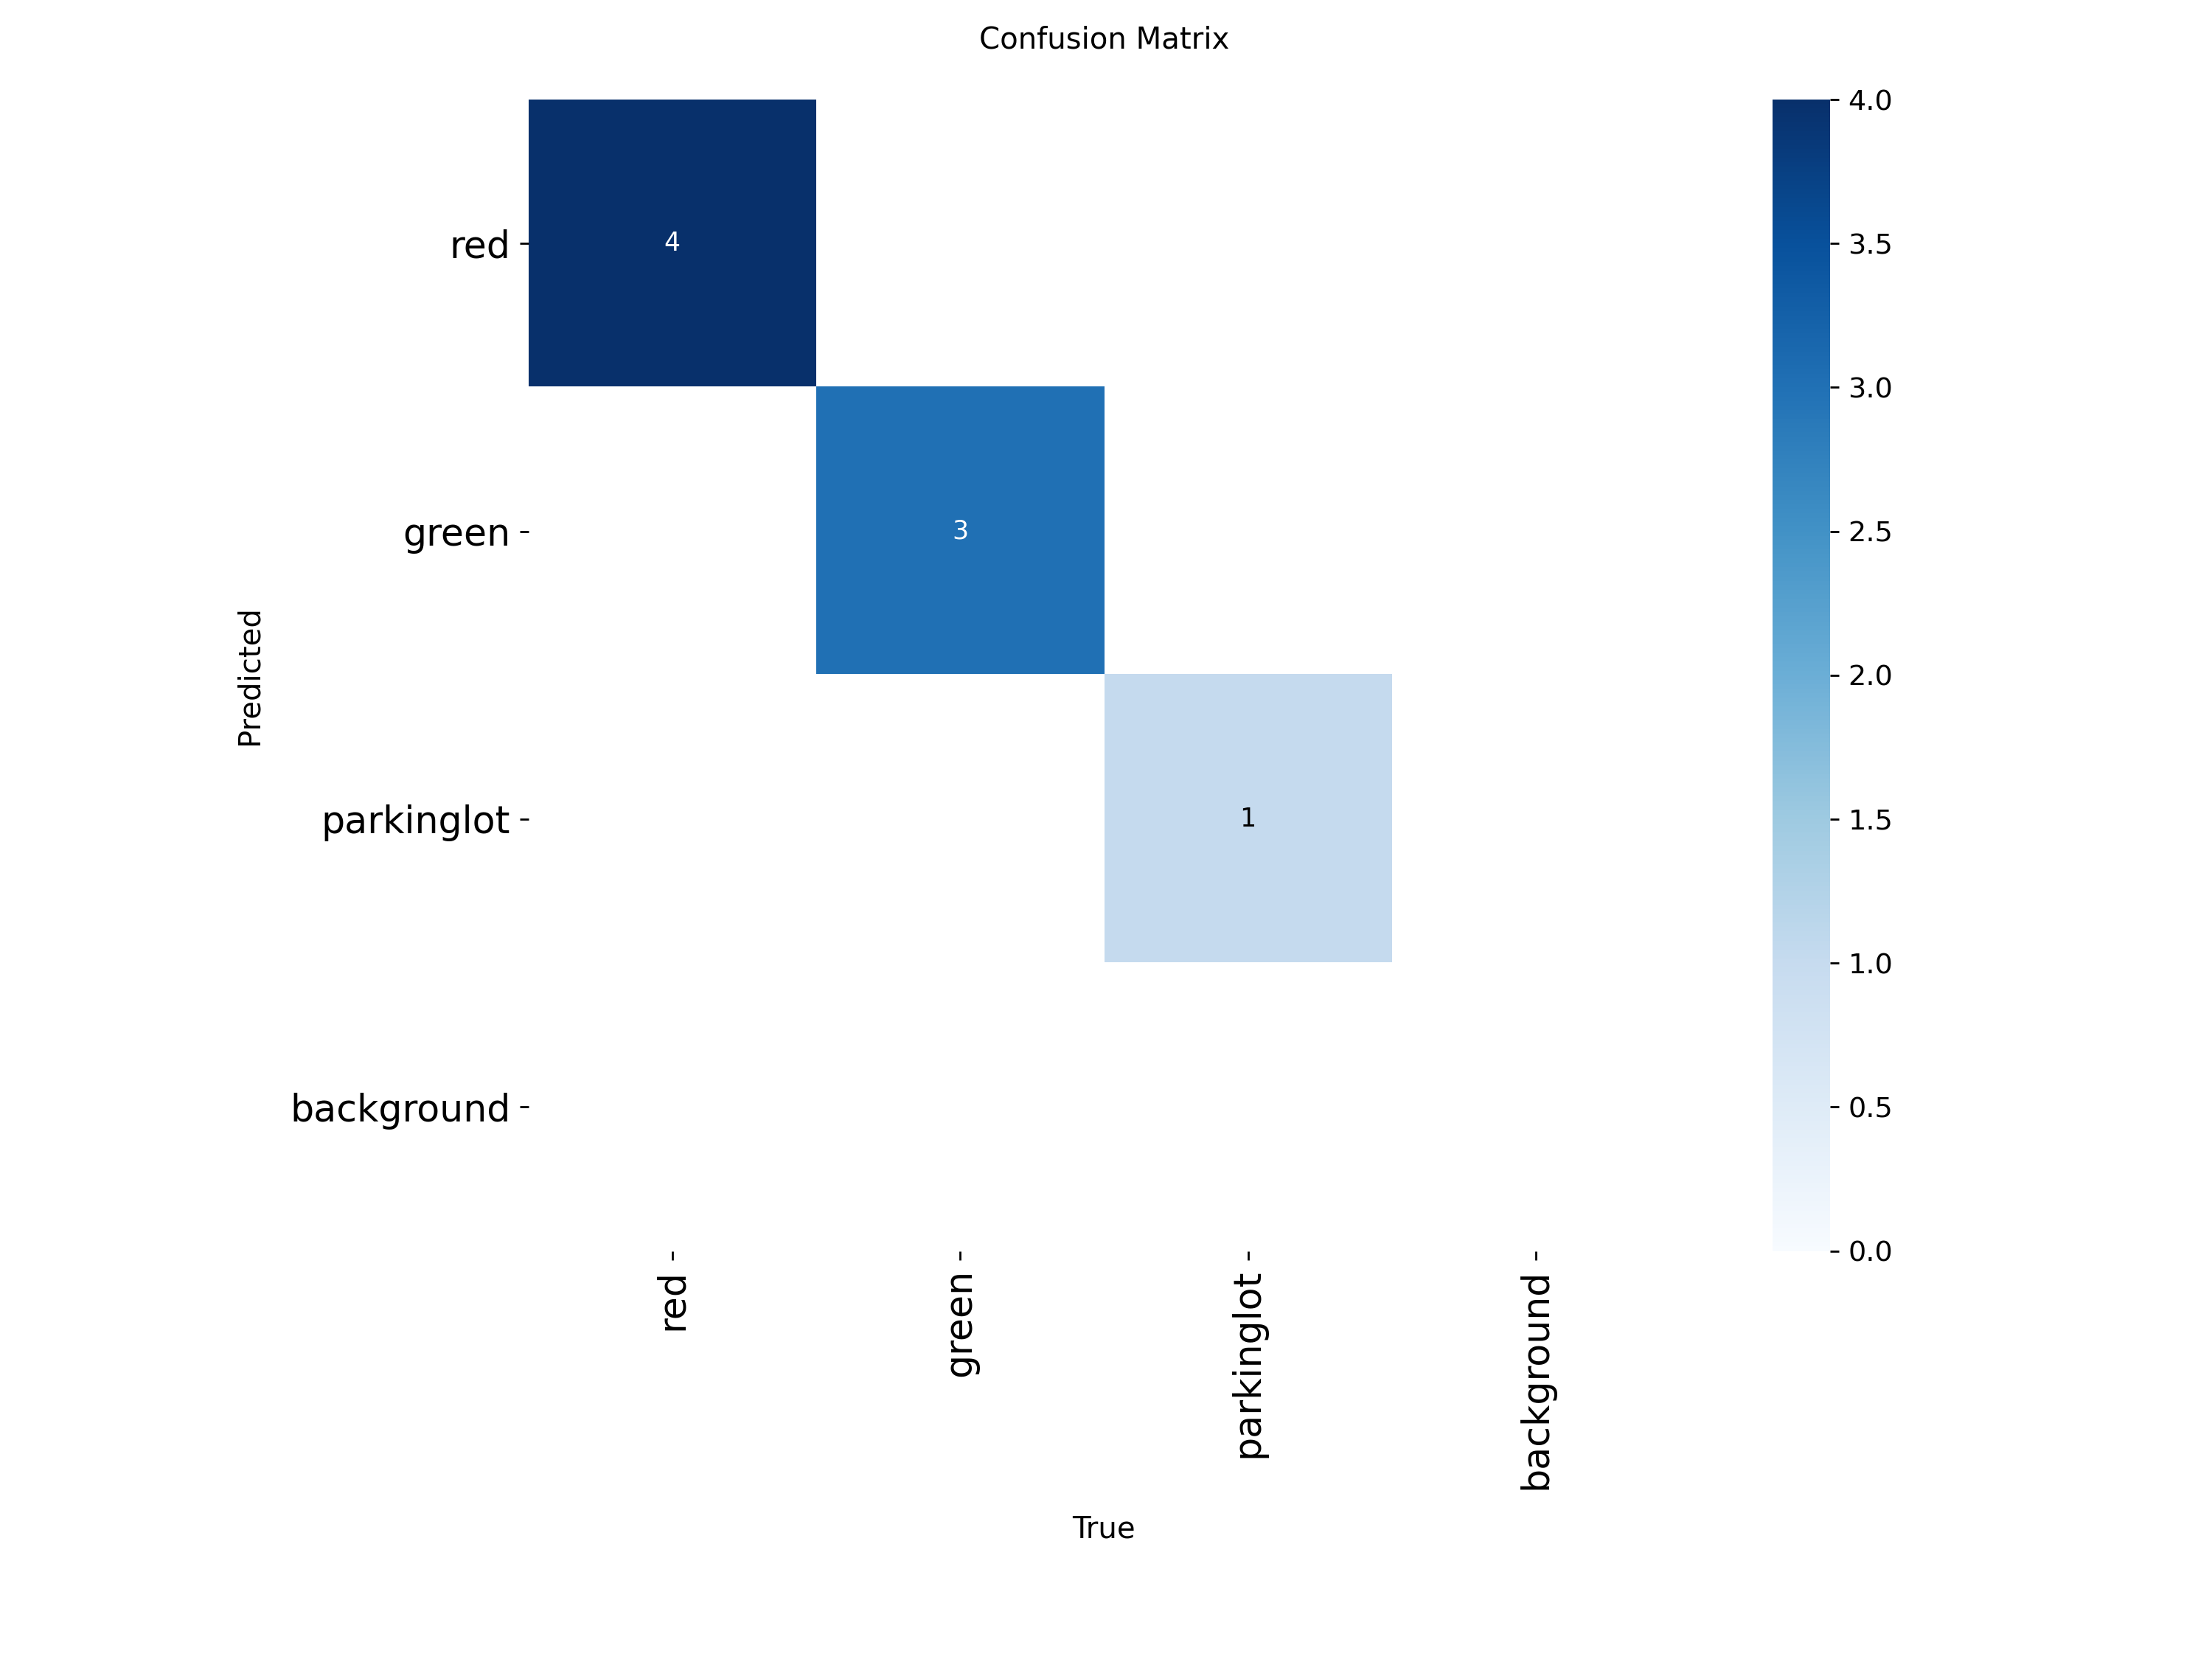

In [ ]:
Image(filename='/content/runs/detect/train/confusion_matrix.png', width=600)

In [ ]:
Image(filename='/content/runs/detect/train/results.png', width=600)

TypeError: 'module' object is not callable

In [ ]:
!yolo task=detect mode=val model=/content/runs/detect/train/weights/best.pt data=/content/dataset/data.yaml

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 962.3±346.7 MB/s, size: 30.1 KB)
val: Scanning /content/dataset/labels/val.cache... 6 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6/6 1.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 6.3it/s 0.2s
                   all          6          8      0.975          1      0.995      0.995
                   red          4          4      0.967          1      0.995      0.995
                 green          3          3      0.993          1      0.995      0.995
            parkinglot          1          1      0.966          1      0.995      0.995
Speed: 1.4ms preprocess, 8.0ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more at https://do

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving photo_20260612_180601.png to photo_20260612_180601.png
Saving photo_20260612_180616.png to photo_20260612_180616.png
Saving photo_20260612_180627.png to photo_20260612_180627.png
Saving photo_20260612_180631.png to photo_20260612_180631.png
Saving photo_20260612_180717.png to photo_20260612_180717.png
Saving photo_20260612_180726.png to photo_20260612_180726.png



image 1/1 /content/photo_20260612_180717.png: 480x640 1 red, 8.2ms
Speed: 3.2ms preprocess, 8.2ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict-8


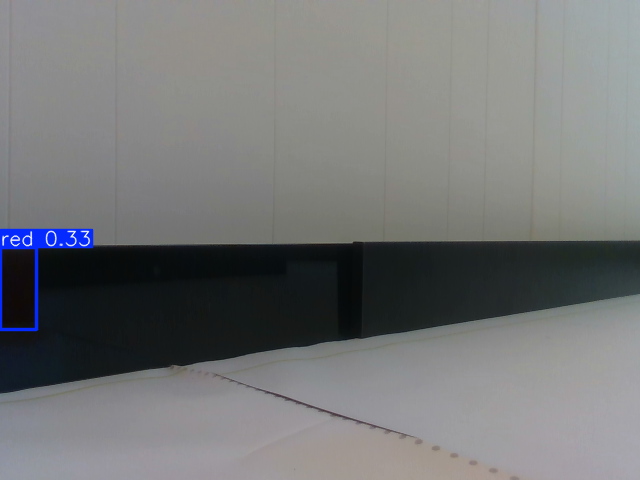

red 0.33  框: (0,247) -> (37,330)


In [ ]:
from ultralytics import YOLO
from PIL import Image

model = YOLO('/content/runs/detect/train/weights/best.pt')
results = model('/content/photo_20260612_180717.png', save=True)

results[0].show()        # 弹出带框的图
# 或者:
Image.fromarray(results[0].plot()[..., ::-1])   # 在 Colab 单元里直接渲染

for box in results[0].boxes:
    cls = model.names[int(box.cls)]          # 类别名
    conf = float(box.conf)                   # 置信度
    x1, y1, x2, y2 = box.xyxy[0].tolist()    # 左上角 + 右下角坐标(像素)
    print(f"{cls} {conf:.2f}  框: ({x1:.0f},{y1:.0f}) -> ({x2:.0f},{y2:.0f})")